# Splits Datasets

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow import keras
import tensorflow as tf

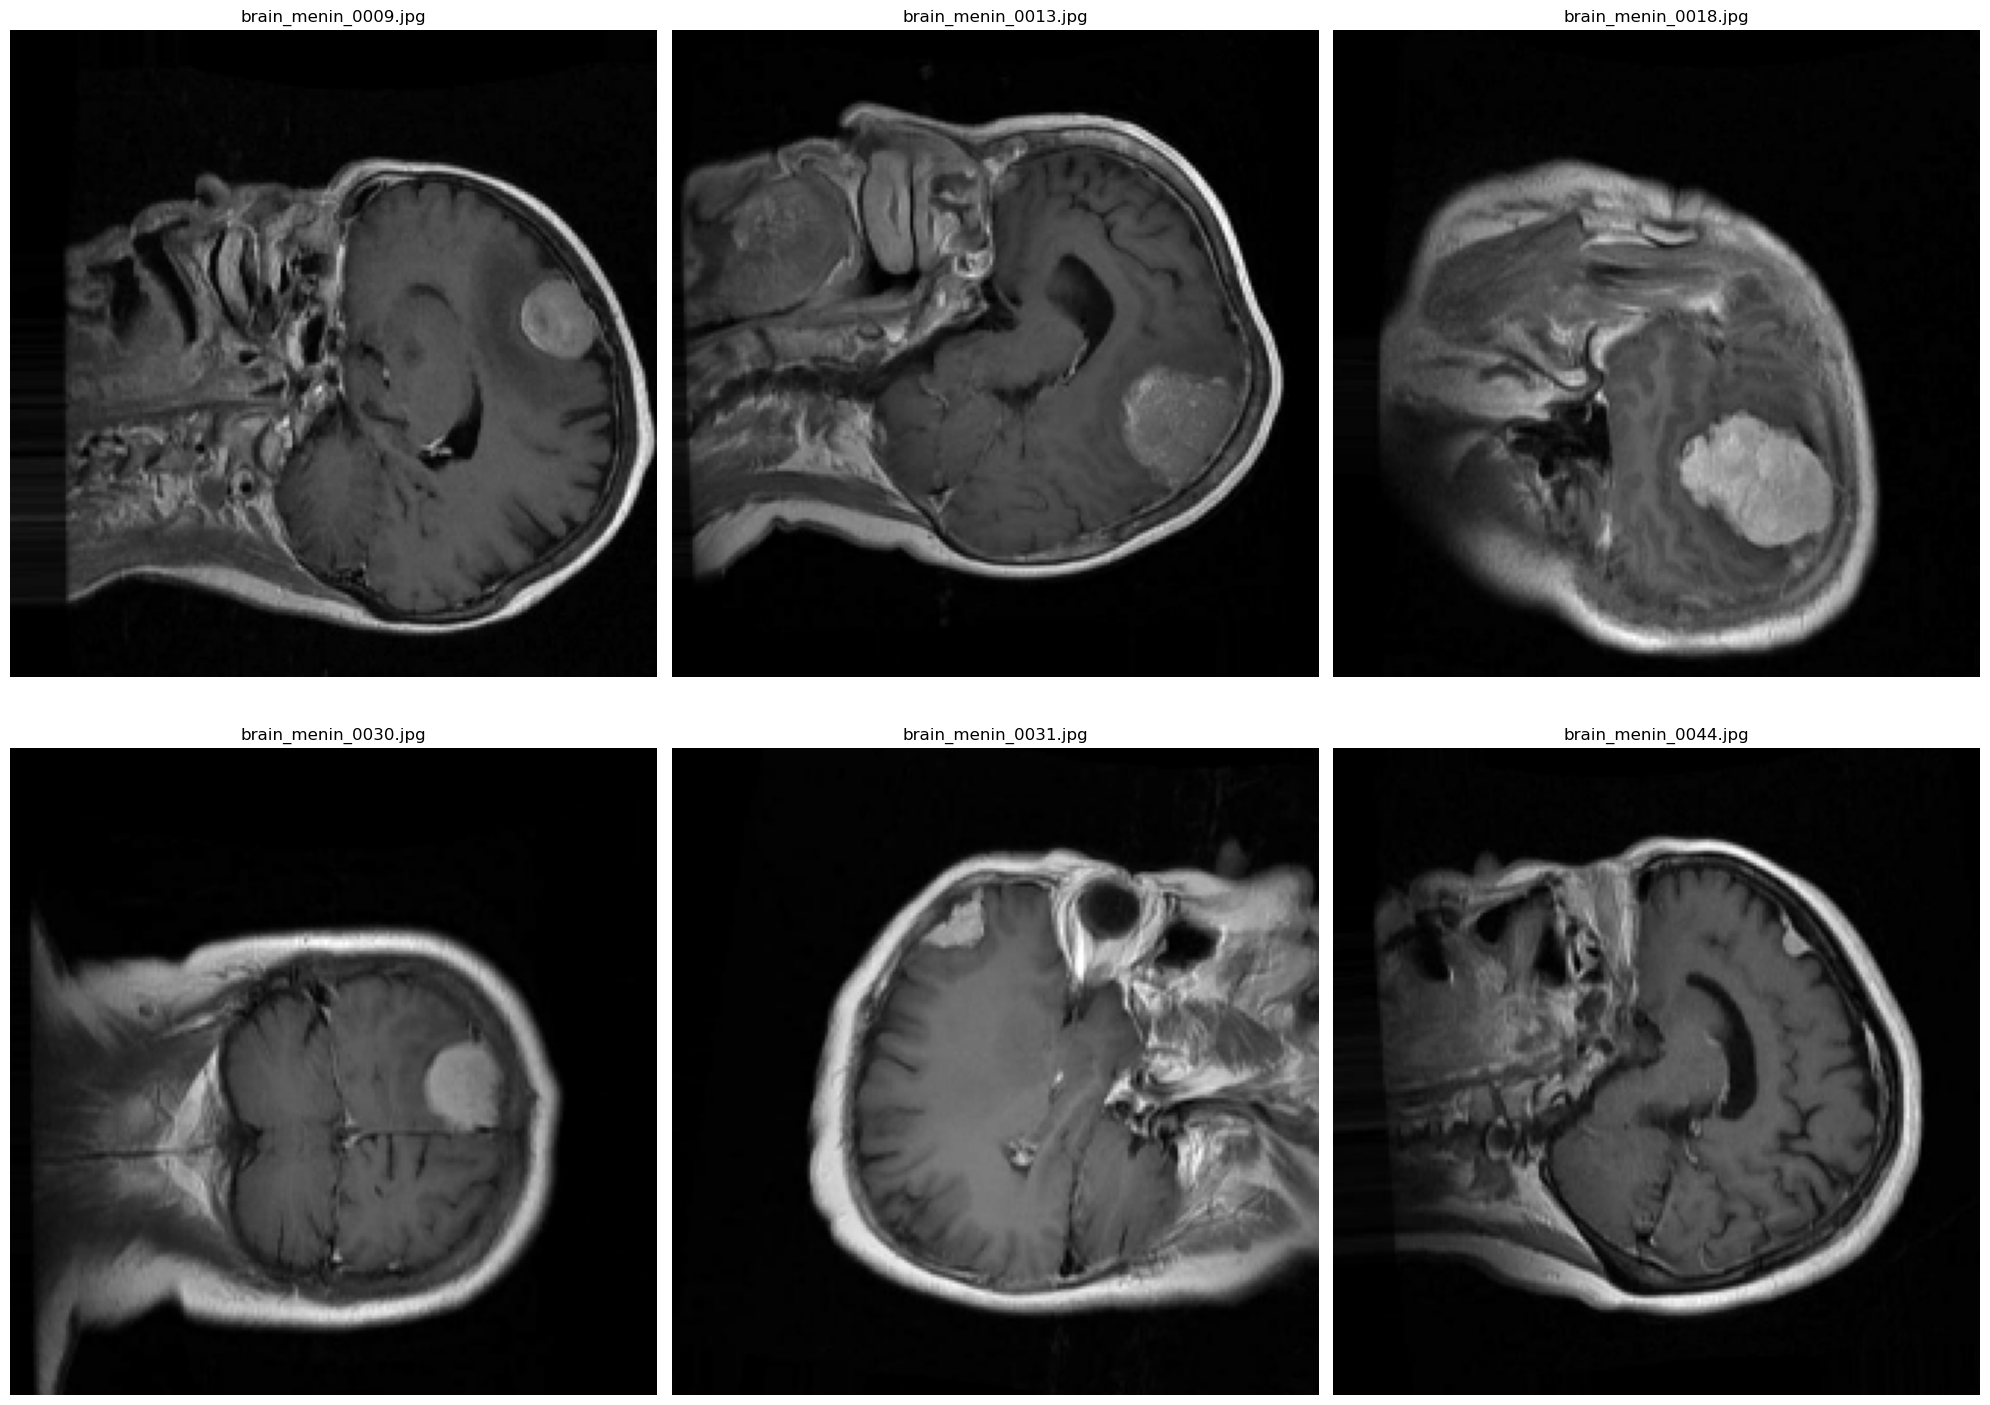

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

img_dir = Path(r"")

exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
files = [p for p in sorted(img_dir.iterdir()) if p.suffix.lower() in exts]
if not files:
    raise RuntimeError(f"No image files found in {img_dir}")


target_size = tuple((220, 220)) 

imgs = []
for p in files[:6]:
    b = tf.io.read_file(str(p))
    img = tf.image.decode_image(b, channels=1)       
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.uint8).numpy().squeeze(-1)   
    imgs.append((img, p.name))

# plot
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i < len(imgs):
        img, name = imgs[i]
        ax.imshow(img, cmap="gray")
        ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

dataset_path = r""
output_path = r""

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15   

for split in ["train", "val", "test"] :
    split_path = os.path.join(output_path, split)
    os.makedirs(split_path, exist_ok=True)

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_path):
        continue

    files = os.listdir(class_path)

    train_files, temp_files = train_test_split(files, test_size=(1-train_ratio), random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=test_ratio/(test_ratio+val_ratio), random_state=42)

    def copy_files(file_list, split):
        split_class_dir = os.path.join(output_path, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)
        for f in file_list:
            shutil.copy(os.path.join(class_path, f), os.path.join(split_class_dir, f))

    copy_files(train_files, "train")
    copy_files(val_files, "val")
    copy_files(test_files, "test")

print("Done! Dataset has been split into train/val/test.")

Done! Dataset has been split into train/val/test.
